# Action Classification Model (ML Baseline)

This notebook implements a dedicated Machine Learning model to predict standard **Support Actions** based on ticket descriptions.

## The 5 Standard Actions
We have standardized our actions into 5 distinct categories:
1. **Initiate Troubleshooting** (from Technical issues)
2. **Review & Explain Charges** (from Billing inquiries)
3. **Process Cancellation** (from Cancellation requests)
4. **Provide Product Specs** (from Product inquiries)
5. **Issue Refund** (from Refund requests)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import classification_report, confusion_matrix

# 1. Load Data
df = pd.read_csv('../data/raw/customer_support_tickets.csv')

# 2. Label Engineering: Map Ticket Type to Standard Actions
action_map = {
    'Technical issue': 'Initiate Troubleshooting',
    'Billing inquiry': 'Review & Explain Charges',
    'Cancellation request': 'Process Cancellation',
    'Product inquiry': 'Provide Product Specs',
    'Refund request': 'Issue Refund'
}

df['Action_Label'] = df['Ticket Type'].map(action_map)

# Fill any missing mappings (just in case) with 'General Support'
df['Action_Label'] = df['Action_Label'].fillna('General Support')

# 3. Feature Engineering: Combine Subject + Body
df['combined_text'] = (df['Ticket Subject'].fillna('') + " " + df['Ticket Description'].fillna('')).str.lower()

print("Data Loaded & Labeled. Shape:", df.shape)
print("\nAction Distribution:")
print(df['Action_Label'].value_counts())

Data Loaded & Labeled. Shape: (8469, 19)

Action Distribution:
Action_Label
Issue Refund                1752
Initiate Troubleshooting    1747
Process Cancellation        1695
Provide Product Specs       1641
Review & Explain Charges    1634
Name: count, dtype: int64


## Train the Model
We use **TF-IDF** (Term Frequency-Inverse Document Frequency) to convert text to numbers, and **LinearSVC** (Support Vector Classifier) to predict the action.

In [3]:
# 1. Vectorization
tfidf = TfidfVectorizer(max_features=5000, stop_words='english', ngram_range=(1,2))
X = tfidf.fit_transform(df['combined_text'])
y = df['Action_Label']

# 2. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. Train Classifier
model = LinearSVC(random_state=42)
model.fit(X_train, y_train)

print("Model Trained Successfully!")

Model Trained Successfully!


## Evaluation
Comparison of predicted actions vs real labels.

--- Classification Report ---
                          precision    recall  f1-score   support

Initiate Troubleshooting       0.21      0.22      0.21       349
            Issue Refund       0.21      0.22      0.21       345
    Process Cancellation       0.20      0.21      0.21       327
   Provide Product Specs       0.18      0.18      0.18       316
Review & Explain Charges       0.18      0.16      0.17       357

                accuracy                           0.20      1694
               macro avg       0.20      0.20      0.20      1694
            weighted avg       0.20      0.20      0.20      1694



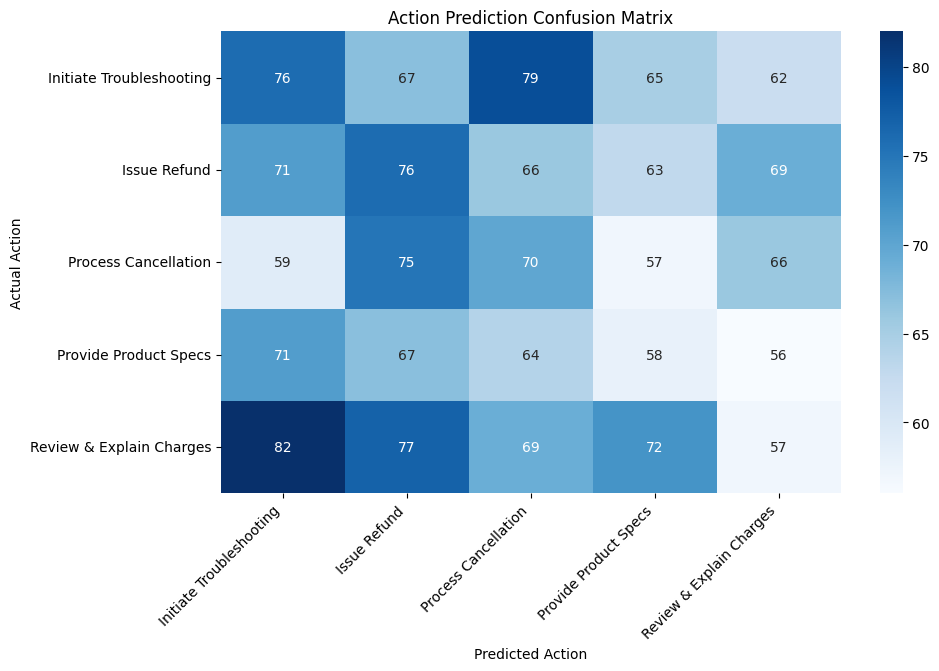

In [4]:
# Predict
y_pred = model.predict(X_test)

# Metrics
print("--- Classification Report ---")
print(classification_report(y_test, y_pred))

# Confusion Matrix Visualization
plt.figure(figsize=(10,6))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=model.classes_, yticklabels=model.classes_)
plt.title('Action Prediction Confusion Matrix')
plt.ylabel('Actual Action')
plt.xlabel('Predicted Action')
plt.xticks(rotation=45, ha='right')
plt.show()

## Test with Custom Examples
Let's see the model in action on new, unseen examples.

In [5]:
def predict_action(text):
    text_vec = tfidf.transform([text.lower()])
    prediction = model.predict(text_vec)[0]
    return prediction

# Test Cases
examples = [
    "My internet is not working and the router red light is blinking",
    "I want to return the shoes I bought yesterday, size is wrong",
    "Why was I charged $50 extra on my bill this month?",
    "Can you tell me the battery life of the iPhone 15?",
    "Please stop my subscription immediately"
]

print(f"{'Input Ticket':<60} | {'Predicted Action':<25}")
print("-" * 90)

for ex in examples:
    pred = predict_action(ex)
    print(f"{ex:<60} | {pred:<25}")

Input Ticket                                                 | Predicted Action         
------------------------------------------------------------------------------------------
My internet is not working and the router red light is blinking | Initiate Troubleshooting 
I want to return the shoes I bought yesterday, size is wrong | Process Cancellation     
Why was I charged $50 extra on my bill this month?           | Process Cancellation     
Can you tell me the battery life of the iPhone 15?           | Provide Product Specs    
Please stop my subscription immediately                      | Initiate Troubleshooting 
